<a href="https://colab.research.google.com/github/sasaitals/Data-Science-testando-rela-es-com-Regress-o-Linear/blob/main/Aula2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
#Lendo os dados
dados = pd.read_csv("/content/Preços_de_casas.csv")

In [7]:
#Fatores coletados
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [8]:
dados = dados.drop(columns = "Id")
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   area_primeiro_andar             1438 non-null   float64
 1   existe_segundo_andar            1438 non-null   int64  
 2   area_segundo_andar              1438 non-null   float64
 3   quantidade_banheiros            1438 non-null   int64  
 4   capacidade_carros_garagem       1438 non-null   int64  
 5   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 6   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 78.8 KB


#Correlação

In [9]:
corr = dados.corr()

In [10]:
#Entendemos que a maior relação do preço da casa, tem a ver com a area do primeiro andar
corr['preco_de_venda']

,preco_de_venda
area_primeiro_andar,0.616557
existe_segundo_andar,0.138541
area_segundo_andar,0.305311
quantidade_banheiros,0.563132
capacidade_carros_garagem,0.640214
qualidade_da_cozinha_Excelente,0.496223
preco_de_venda,1.000000


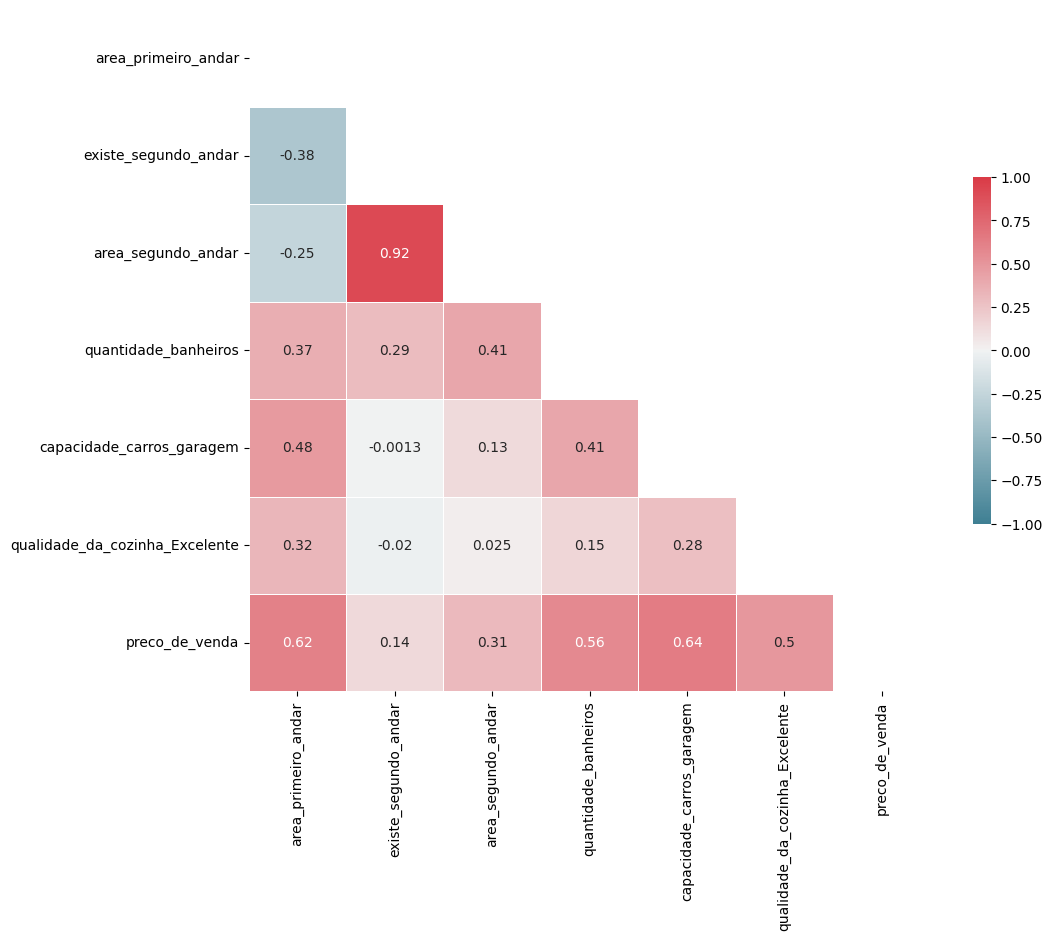

In [11]:
# Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar a figura do matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Exibir o mapa de calor (heatmap)
plt.show()
#Gráfico de dispersao

Text(0, 0.5, 'Preço de Venda')

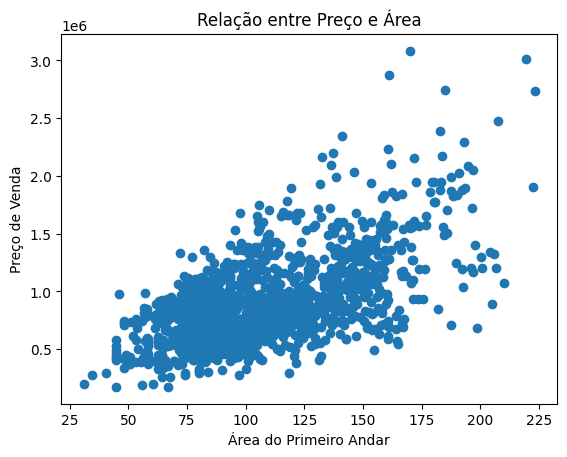

In [12]:
#Como é a relação entre área contruida e preço do imóvel

plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.title("Relação entre Preço e Área")
plt.xlabel("Área do Primeiro Andar")
plt.ylabel("Preço de Venda")

Text(0, 0.5, 'Preço de Venda')

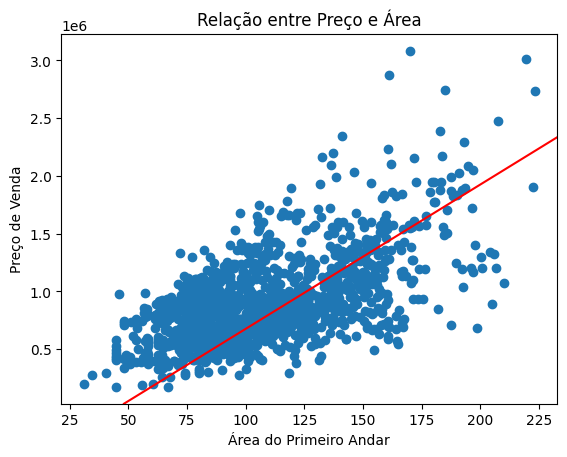

In [13]:
#Quanto maior a área do primeiro andar, maior o preço da casa
#Traçar uma linha pata melhor representar:
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.axline(xy1 = (66, 250000),xy2 = (190, 1800000), color = "red")

plt.title("Relação entre Preço e Área")
plt.xlabel("Área do Primeiro Andar")
plt.ylabel("Preço de Venda")

#Exemplificando de forma linear a relação de preço e a area, mas essa linha foi feita de forma manual, nos que colocamos os dados, a maquina não os analisou para traçar a linha

#Melor reta

In [14]:
px.scatter(dados, x = 'area_primeiro_andar', y = 'preco_de_venda', trendline_color_override="red", trendline='ols')

#Ajuste da reta
Fórmula **Yᵢ = B₀ + B₁ * Xᵢ**

Seria como dizer **Preço de Venda = (Valor Base do Imóvel) + (Impacto da Área no Preço) * (Área do Primeiro Andar)**

Esta linha nos ajuda a visualizar como a `area_primeiro_andar` explica o
`preco_de_venda`

#Variaveis respostas e explicativas
A variavel resposta é aquela que queremos prever ou explicar, no caso é o `preco_de_venda` e a variavel explicativa é aquela que iremos utilixar para chegar na variavel resposta, no caso, `area_primeiro_andar`

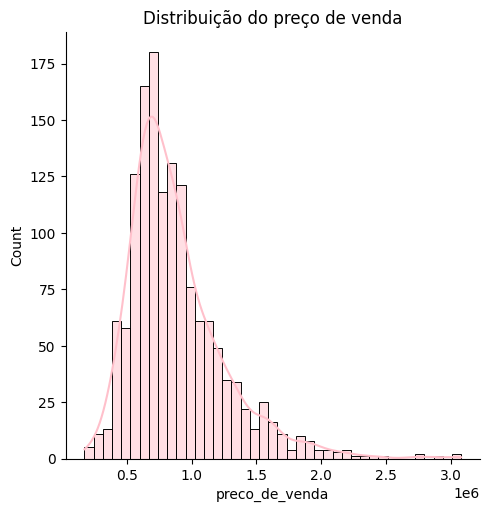

In [15]:
sns.displot(dados['preco_de_venda'], kde=True, color='pink')
plt.title('Distribuição do preço de venda')
plt.show()

#Treino e teste

In [16]:
from sklearn.model_selection import train_test_split

In [18]:
#x os dados que serão analisados para adquirir o y

y = dados['preco_de_venda'] #y é o dado que queremos alcançar
x = dados.drop(columns = 'preco_de_venda') #traduz para "a tabela inteira menos a coluna preco_de_venda". Estes dados serão analisados para adquirir a resposta = ao y

In [20]:
x_train, x_teste, y_train, y_teste = train_test_split(x, y, test_size = 0.3, random_state= 230)
#O random_state serve para que toda vez que o train_test_split coloque o mesmo conjunto de dados no teste e no treino para assim, toda vez que o sistema for executado, tera sempre os msmos dados em treino e teste

In [21]:
#x_trains são organizados em df_train. Não precisa passar os dados pelo Dataframe toda vez, vamos utilizar ele pois o ols espera que os dados fornecidos sejam em DataFrame
df_train = pd.DataFrame(data= x_train) #Colocando todos os dados de treino no DataFrame
#colocando as "respostas" no DataFrame
df_train['preco_de_venda'] = y_train #Adicionando uma coluna com o nome 'preco_de_venda' com os dados de "resposta treino"
#Acima colocamos TODAS as variaveis que serão utilizadas (x-pergunta e y-resposta) em um unico DataFrame para que o ols coniga receber todos

In [22]:
from statsmodels.formula.api import ols

In [23]:
modelo_0 = ols('preco_de_venda ~ area_primeiro_andar', data = df_train).fit() #.fit() SEMPRE ira trinar o modelo
#A parte "'preco_de_venda ~ area_primeiro_andar'" equivale a dizer "Queremos modelar o preco_de_venda em função da area_primeiro_andar"

#Analisando os coeficientes

In [24]:
modelo_0.params
#Interceptor: Caso a area do primeiro andar for 0, o preço da casa iniciará com base de R$152.909,28, ou seja, os valores irão sempre iniciar ou ser acima deste preço
#Efeito Individual: é o valor 6793.64, ou sejá, espera-se que a cada metro quadrado adicionado, o valor da casa aumente em média R$6.793,64

,0
Intercept,152909.288334
area_primeiro_andar,6793.641641


In [26]:
print(modelo_0.summary())
#Quando o P>|t| está muito baixo, significa que ele tem um valor significativo no valor da casa
#As duas linhas acima foi para identificar o quanto de realção a area_primeiro_andar tem com o valor da casa

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Sun, 06 Sep 2026   Prob (F-statistic):          2.22e-105
Time:                        18:27:10   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.529e+05   3

In [28]:
modelo_0.rsquared *100
#pode-se explicar que 37.72% da diferença dos preços da casa é por causa da area do primeiro andar
#quanto mais perto de 1 (100%) melhor é
#Resume-se para: a área do primeiro andar não é determinante para o valor da casa

np.float64(37.72801099429787)

In [29]:
modelo_0.resid

,0
1303,-193023.838744
326,-144522.356193
386,399612.747641
615,-68449.596607
236,166010.592859
...,...
777,465872.680999
271,-497642.319788
723,461150.204718
560,-540482.733402


<function matplotlib.pyplot.show(close=None, block=None)>

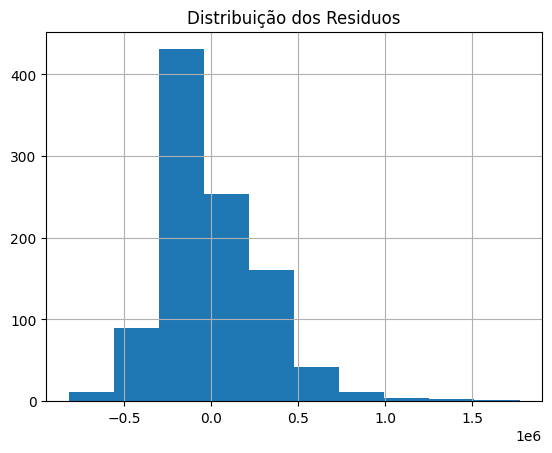

In [30]:
modelo_0.resid.hist()
plt.title("Distribuição dos Residuos")
plt.show
#Espera-se que os residuos estejam bem proximos de 0, pois resulta em  boas métricas de avaliação, mostrando que o modelo é preciso e assertivo.

In [31]:
#após treinar e ajustar o modelo, vamos avaliar sua capacidade de prever com precisão
y_predict = modelo_0.predict(x_teste)

In [32]:
from sklearn.metrics import r2_score

In [35]:
print("R²: ", r2_score(y_teste, y_predict))
#O valor abaixo está muito parecido com os valores reais de 38%,
#porém, apenas 38% dos valores das casas são explicados pela area do primeiro andar

R²:  0.38530928723202407
